In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
from time import time

# 1. Beam-Warming method (4 points)
The Beam-Warming method for the linear advection equation $u_t + au_x =0$ is given by
$$ U^{n+1}_j = U^n_j - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) +
  \frac{a^2 k^2}{2h^2} (U^n_j - 2U^n_{j-1} + U^n_{j-2}) $$
where $U^n_j$ is the approximation of $u(jh,nk)$.

1. Use Taylor series to show that this method is second-order accurate.
2. For a given plane wave solution $U^0_j = e^{ij h \xi}$, compute the amplification factor $g(\xi)$, and hence determine the stability restriction for this method.

### Part 1

We use the expansions
\begin{align*}
    U^{n+1}_j &= u(jh, nk + k) = U_j^n + k u_t(jh, nk) + \frac{k^2}{2} u_{tt}(jh, nk) + \frac{k^3}{6} u_{ttt}(jh, nk) + O(k^4) \\
    U^n_{j-1} &= u(jh - h, nk) = U_j^n - h u_x(jh, nk) + \frac{h^2}{2} u_{xx}(jh, nk) - \frac{h^3}{6} u_{xxx}(jh, nk) + O(h^4) \\
    U^n_{j-2} &= u(jh -2h, nk) = U_j^n - 2hu_x(jh, nk) + 2h^2 u_{xx}(jh, nk) - \frac{4h^3}{3} u_{xxx}(jh, nk) + O(h^4)
\end{align*}

which allows us to expand the terms
\begin{align*}
    3U_j^n - 4U_{j-1}^n + U_{j-2}^n &= 2hu_x - \frac{2h^3}{3} u_{xxx} + O(h^4) \\
    U_j^n - 2U_{j-1}^n + U_{j-2}^n &= h^2 u_{xx} - h^3 u_{xxx} + O(h^4)
\end{align*}

If we assume that $u$ is smooth, then we also have
$$ u_t = -au_x \qquad u_{tt} = -a u_{xt} = -a u_{tx} = -a (-a u_{xx}) = a^2 u_{xx} $$

We write the iterative step as
$$ LHS = U_j^{n+1} - U_j^n = - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) + \frac{a^2 k^2}{2h^2} (U^n_j - 2U^n_{j-1} + U^n_{j-2}) = RHS $$
and expand both sides using the above
\begin{align*}
    LHS &= ku_t + \frac{k^2}{2} u_{tt} + \frac{k^3}{6} u_{ttt} + \cdots \\
    &= -ak u_x + \frac{a^2k^2}{2} u_{xx} + O(k^3) \\
    RHS &= \left( -ak u_x + \frac{a kh^2}{3} u_{xxx} + \cdots \right) + \left( \frac{a^2k^2}{2} u_{xx} - \frac{a^2k^2h}{2} u_{xxx} + \cdots \right) \\
    &= -ak u_x + \frac{a^2k^2}{2} u_{xx} + O(h^3 + k^3)
\end{align*}

Thus both sides agree up to second order in $h$ and $k$, so this method is second-order accurate.

### Part 2
For the given solution, we get
$$ U^1_{j} = g(\xi) e^{ijh\zeta} = e^{ijh\zeta} - \frac{ak}{2h}(3 - 4e^{-ih\xi} + e^{-2ih\xi}) e^{ijh\xi} + \frac{a^2k^2}{2h^2} (1 - 2e^{-ih\xi} + e^{-2ih\xi}) e^{ijh\xi} $$
so the amplification factor is
\begin{align*}
    g(\xi) &= 1 - \frac{ak}{2h}(3 - 4e^{-ih\xi} + e^{-2ih\xi}) + \frac{a^2k^2}{2h^2} (1 - 2e^{-ih\xi} + e^{-2ih\xi}) \\
    &= (1 - \frac{3\nu}{2} + \frac{\nu^2}{2}) + (2\nu - \nu^2) e^{-ix} + ( \frac{\nu^2}{2} - \frac{\nu}{2} ) e^{-2ix} \\
    g(x) &= A + B e^{-ix} + C e^{-2ix}
\end{align*}

Where we define $x = h\xi$ and $\nu = ak/h$.

When we take the norm, we end up getting some terms in $\cos(x)$, so we can just look at $g(0)$ and $g(\pi)$. 
\begin{align*}
    g(0) &= A + B + C = 1 \\
    g(\pi) &= A - B + C = 1 - 4\nu + 2\nu^2
\end{align*}

Clearly $|g(0)| \leq 1$ always, so we just need to solve
\begin{gather*}
    |1 - 4\nu + 2\nu^2| \leq 1 \\
    -1 \leq 1 - 4\nu + 2\nu^2 \leq 1
\end{gather*}
which gives the stability restrictions $2(\nu - 1)^2 \geq 0$ and $2\nu(\nu - 2) \leq 0$, which simplifies to
$$ 0 \leq \nu \leq 2$$

# 2. Beam-Warming cont. (9 points)
Dropping the last term in the Beam-Warming method gives
$$ U^{n+1}_j = U^n_j - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) $$
which corresponds to forward Euler method in time, and a second-order one-sided derivative in space. Define $\nu = ak/h$.

1. Calculate the amplification factor $g(\xi)$ for a plane wave solution $U^0_j = e^{ijh\xi}$.
2. Define $A(\xi)= |g(\xi)|^2$ and calculate a Taylor series for $A$ at $\xi=0$ up to second order. Using the Taylor series, explain why we consider this numerical scheme to be unstable regardless of the choice of timestep.
3. Make two plots of $A(\xi)$ for $\nu = \frac{1}{100}$ using two different axis ranges:
    * $0\le h\xi \le 2\pi$ and $0.91 \le A \le 1.01$
    * $0\le h\xi \le 0.17$ and $1-10^{-6} \le A \le 1+10^{-6}$
4. Write a program to simulate this scheme on a periodic interval $[0,2\pi)$ using $N=40$ grid points and a grid spacing of $h = 2\pi/N$. Use the initial condition $u= \exp (2\sin x)$ and $\nu =\frac1{100}$. Plot the solution for $n=0,1000,2000,4000$. Define the root mean squared value of the solution,
$$ R(n) = \sqrt{\frac{1}{N} \sum_{j=0}^{N-1} (U^n_j)^2} $$
    Make a plot of $R$ over the range from $n=0$ to $n=10000$. You should find that $R$ does not grow over time, indicating that the method is stable.
5. Using the discrete Fourier transform, it can be shown that an arbitrary initial condition on the periodic interval can be written as
$$ U^0_j = \sum_{l=0}^{N-1} \alpha_l e^{ijlh} $$
    for some constants $\alpha_l$. Write down an expression for the general solution $U^n_j$. Using your answer, explain why your result in part (d) does not contradict the result in part (b).

### Part 1

From the previous part
$$ g(\xi) = 1 - \frac{\nu}{2} \left( 3 - 4e^{-ih\xi} + e^{-2ih\xi} \right) $$

### Part 2

Expanding out the norm, we get
$$ A(\xi) = 1 - \nu(3 - 4\cos(x) + \cos(2x)) + \frac{\nu^2}{2}(13 - 16\cos(x) + 3\cos(2x))$$
where $x = \xi h$. The cosines can be Taylor expanded to second order
$$ \cos(x) = 1 - \frac{x^2}{2} + O(x^4) \qquad \cos(2x) = 1 - 2x^2 + O(x^4) $$

Thus the amplitude to second order is
$$ A(\xi h) = 1 + \nu^2\xi^2h^2 \geq 1$$
so this method is unstable regardless of timestep because we need $A(\xi h) \leq 1$ for stability.

### Part 3

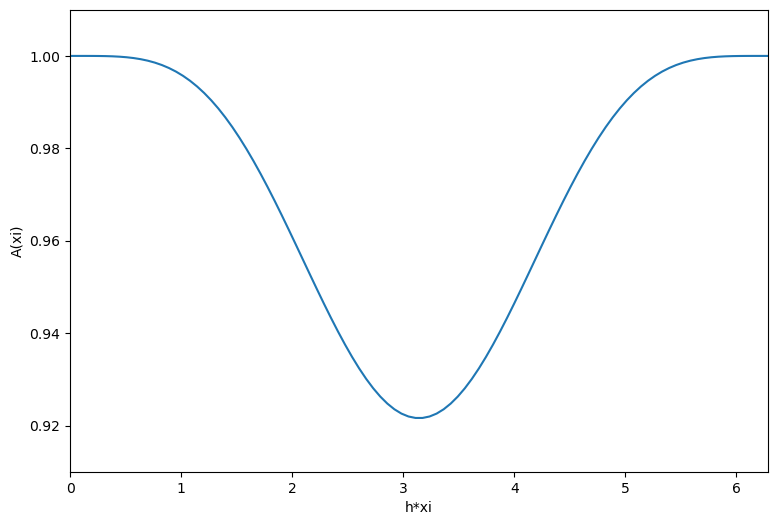

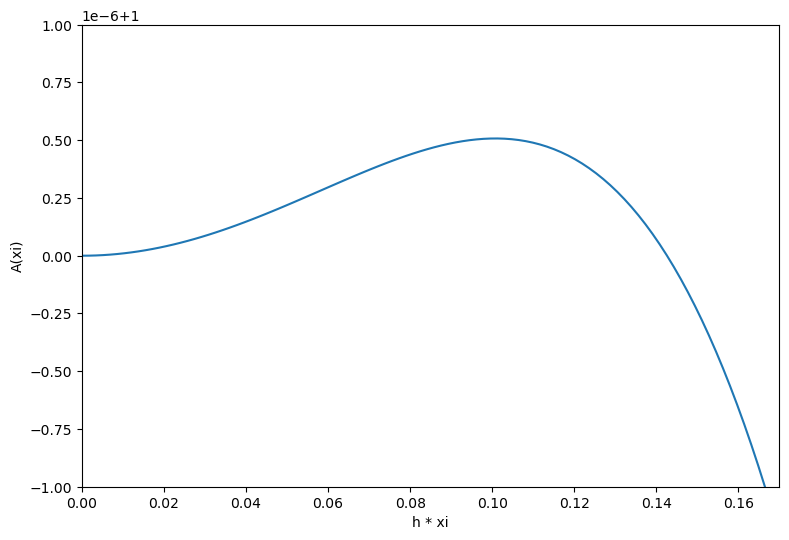

In [2]:
nu = 1/100

def A(x):
    return np.abs(1 - (nu/2) * (3 - 4*np.exp(-1j * x) + np.exp(-2 * 1j * x)))**2

hxis = np.linspace(0, 2 * np.pi, 100)
As = [A(hxi) for hxi in hxis]

plt.figure(figsize=(9,6))
plt.plot(hxis, As)
plt.xlabel('h*xi')
plt.ylabel('A(xi)')
plt.xlim(0, 2 * np.pi)
plt.ylim(0.91, 1.01)
plt.show()

hxis = np.linspace(0, 0.17, 100)
As = [A(hxi) for hxi in hxis]

plt.figure(figsize=(9,6))
plt.plot(hxis, As)
plt.xlabel('h * xi')
plt.ylabel('A(xi)')
plt.xlim(0, 0.17)
plt.ylim(1 - (1e-6), 1 + (1e-6))
plt.show()

### Part 4

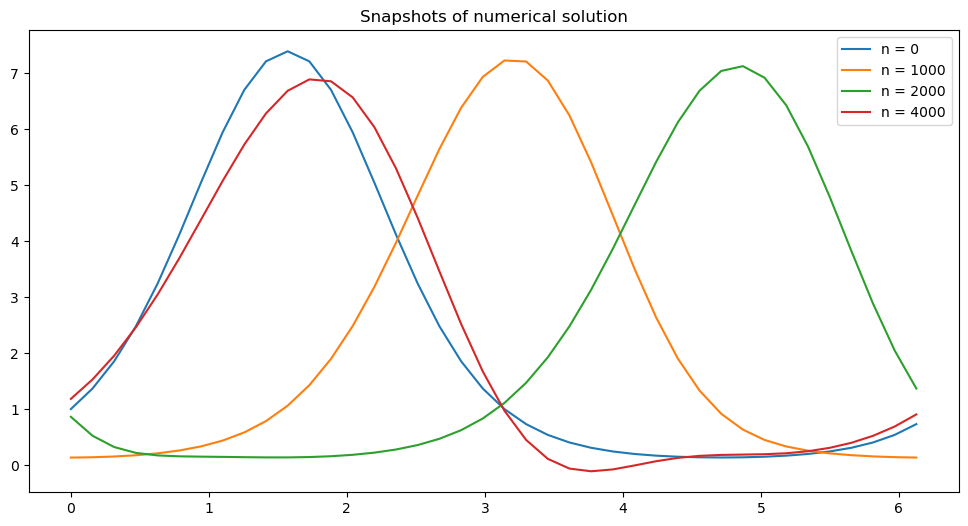

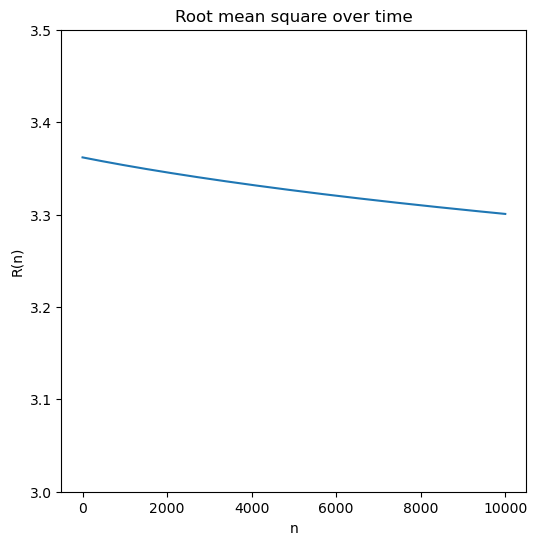

In [7]:
N = 40
h = np.pi*2/N
nu = 1/100
coeffs = [3, -4, 1]
        
def rms(u):
    return np.sqrt(np.linalg.norm(u)**2 / N)

def step(u):
    u0 = u.copy()
    for j in range(len(u)):
        diff = 0
        for i in range(3):
            diff += u0[(j - i) % N] * coeffs[i]  # add periodic boundaries
        u[j] -= (nu/2) * diff 
    return u

xs = [h*i for i in range(N)]
u = [np.exp(2 * np.sin(x)) for x in xs]
Rs = [rms(u)]

plt.figure(figsize=(12,6))
plt.plot(xs, u, label = "n = 0")
for n in range(10000):
    u = step(u)
    Rs.append(rms(u))
    if n+1 in [1000,2000,4000]:
        plt.plot(xs, u, label = f"n = {n+1}")
plt.legend(loc="upper right")
plt.title("Snapshots of numerical solution")
plt.show()

plt.figure(figsize=(6,6))
plt.plot(range(10001), Rs)
plt.title("Root mean square over time")
plt.ylim(3, 3.5)
plt.xlabel("n")
plt.ylabel("R(n)")
plt.show()

### Part 5

Using the discrete Fourier transform, we get that the general solution is
$$ U^n_j = \sum_{l=0}^{N-1} \alpha_l g(l)^n e^{ijlh} $$
since $g(l)$ can only take on discrete values, we avoid hitting the instability we found in part 2.

# 3. Lax-Wendroff method (7 points)
Consider the hyperbolic conservation equation
$$ q_t + [A(x) q]_x =0 $$
for a function on $q(x,t)$ on the periodic interval $[0,2\pi)$. Let 
$$A(x)=2+\frac{4}{3}\sin x$$

Following the finite volume approach, divide the intervals into $m$ domains $\mathcal{C}_i$ of length $h=\frac{2\pi}{m}$, for $i=\{0,1,\ldots,m-1\}$. Let 
$$Q_i^n \approx q \left( \left(i+\frac{1}{2} \right)h, n\Delta t \right)$$ 

be the discretized solution at the center of each $\mathcal{C}_i$. The generalized Lax-Wendroff scheme for this equation is given by
$$ Q^{n+1}_i = Q_i - \frac{\Delta t}{h} \left[ \mathcal{F}_{i+1/2}^n - \mathcal{F}_{i-1/2}^n \right] $$
where the fluxes are
$$ \mathcal{F}_{i-1/2}^n = \frac{A_{i-1} Q_{i-1}^n + A_i Q_i^n}{2} - \frac{A_{i-1/2}\Delta t}{2h} \left[A_iQ^n_i - A_{i-1}Q_{i-1}^n\right] $$

Here, 
$$A_i = A\left( (i + 1/2)h \right) \qquad A_{i-1/2}=A(ih)$$

It can be shown that the solution is time-periodic so that $q(x,t+T)=q(x,t)$ where $T=3\pi/\sqrt{5}$.

1. The CFL condition requires that $\Delta t \le \frac{h}{c}$ for stability. What is $c$ in this case?
2. Implement the method and set $\Delta t = \frac{h}{3c}$. Use the initial condition
$$ q(x,0) = \exp\left(\sin x + \frac{1}{2}\sin 4x\right) $$
    For $m=512$, plot snapshots of the solution for $t=0,\frac{T}{4},\frac{T}{2},\frac{3T}{4},T$. (Since multiples of $\Delta t$ do not exactly match these snapshot times, you may need to make a small adjustment to the timestep)
3. By considering a range of $m$ (e.g. $\sim 256$ and upward) with the initial condition in part (b), calculate the $L_2$ norm between the numerical solution at $t=T$ and the exact answer. Determine the order of convergence. When determining the order of convergence, you are interested in the asymptotic properites of error as $m$ gets large. You can ignore initial transients in error.
4. Repeat parts (b) and (c) for the initial condition
$$ q(x,0) = \max \left\{ \frac{\pi}{2}-|x-\pi|,0 \right\} $$

### Part 1

To satisfy the CFL condition, we need
$$ c \leq \max_{x} |A(x)| = \frac{10}{3} $$

### Part 2

The relevant steps are
$$ Q^{n+1}_i = Q_i - \frac{\Delta t}{h} \left[ \mathcal{F}_{i+1/2}^n - \mathcal{F}_{i-1/2}^n \right] $$

$$ \mathcal{F}_{i-1/2}^n = \frac{A_{i-1} Q_{i-1}^n + A_i Q_i^n}{2} - \frac{A_{i-1/2}\Delta t}{2h} \left[A_iQ^n_i - A_{i-1}Q_{i-1}^n\right] $$

$$ \mathcal{F}_{i+1/2}^n = \frac{A_{i+1} Q_{i+1}^n + A_i Q_i^n}{2} - \frac{A_{i+1/2}\Delta t}{2h} \left[A_{i+1}Q^n_{i+1} - A_i Q_i^n \right] $$

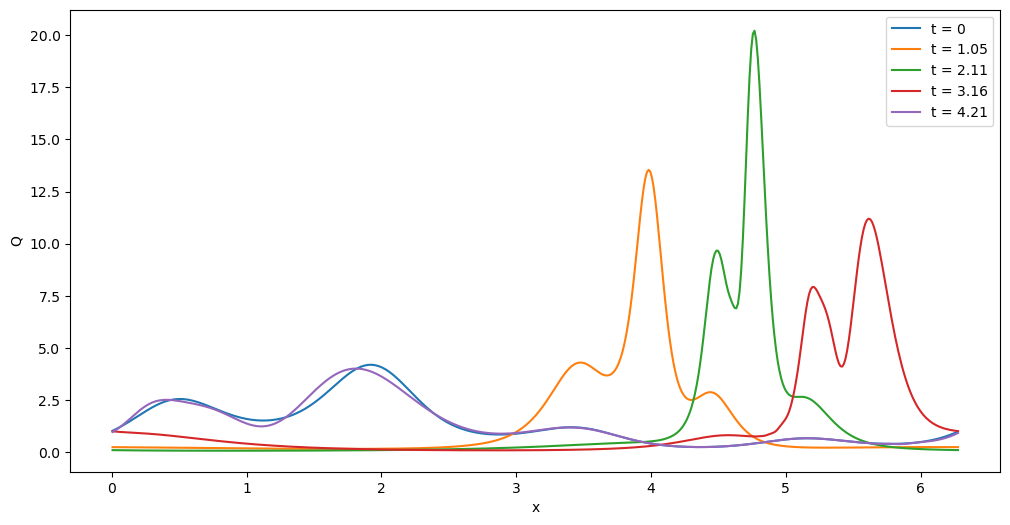

In [38]:
m = 512
h = 2*np.pi/m
T = 3*np.pi/np.sqrt(5)
dt = h/(3*c)
c = 10/3

def A(i, h):
    return 2 + (4/3) * np.sin((i+1/2) * h)

def step(Q, dt, h):
    Q0 = Q.copy()
    for i in range(len(Q)):
        f_minus = (A(i-1, h) * Q0[(i-1)%m] + A(i, h) * Q0[i]) / 2
        f_minus -= (A(i-(1/2), h) * dt) / (2*h) * (A(i, h) * Q0[i] - A(i-1, h) * Q0[(i-1)%m])
        f_plus = (A(i+1, h) * Q0[(i+1)%m] + A(i, h) * Q0[i]) / 2
        f_plus -= (A(i+(1/2), h) * dt) / (2*h) * (A(i+1, h) * Q0[(i+1)%m] - A(i, h) * Q0[i])
        Q[i] -= (dt/h) * (f_plus - f_minus)
    return Q

def q(x):
    return np.exp(np.sin(x) + 0.5 * np.sin(4*x))

# adjust the time-step to meet the desired snapshots and make it a multiple of 4
dt = T/(np.ceil(T/dt/4)*4)
N = int(T/dt)
snapshots = [i * N//4 for i in range(5)]
xs = [(i+1/2)*h for i in range(m)]
Q = [q(x) for x in xs]

plt.figure(figsize=(12,6))
plt.plot(xs, Q, label="t = 0")
for t in range(N):
    Q = step(Q, dt, h)
    if (t+1) in snapshots:
        plt.plot(xs, Q, label = f"t = {(t+1)*dt:.3}")
plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("Q")
plt.show()

### Part 3

256 8.25013513755296
512 3.8536269925278526
1024 1.478295976040723

a=8.27e+03	 b=-1.24


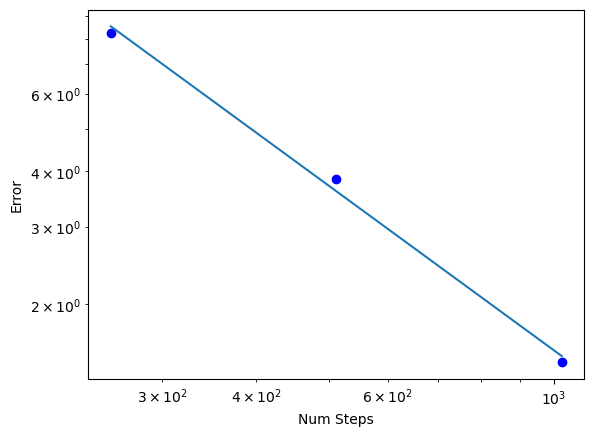

In [40]:
ms = [256, 512, 1024]
errs = []
    
for m in ms:
    h = 2*np.pi/m
    T = 3*np.pi/np.sqrt(5)
    dt = h/(3*c)
    dt = T/(np.ceil(T/dt/4)*4)
    N = int(T/dt)
    
    xs = [(i+1/2)*h for i in range(m)]
    Q = np.array([q(x) for x in xs])
    actual = np.array([q(x) for x in xs])
    for t in range(N):
        Q = step(Q, dt, h)
    err = np.linalg.norm(Q - actual)
    print(m, err)
    errs.append(err)

C = np.asmatrix([[np.log(m), 1] for m in ms])
b, a = np.linalg.lstsq(C, np.log(errs), rcond=None)[0]

a = np.exp(a)
fit = [a*m**b for m in ms]
print(f"\na={a:.3}\t b={b:.3}")

plt.loglog(ms, errs, 'bo')
plt.loglog(ms, fit)
plt.xlabel("Num Steps")
plt.ylabel("Error")
plt.show()

From this we see that error decreases linearly with step size.

### Part 4

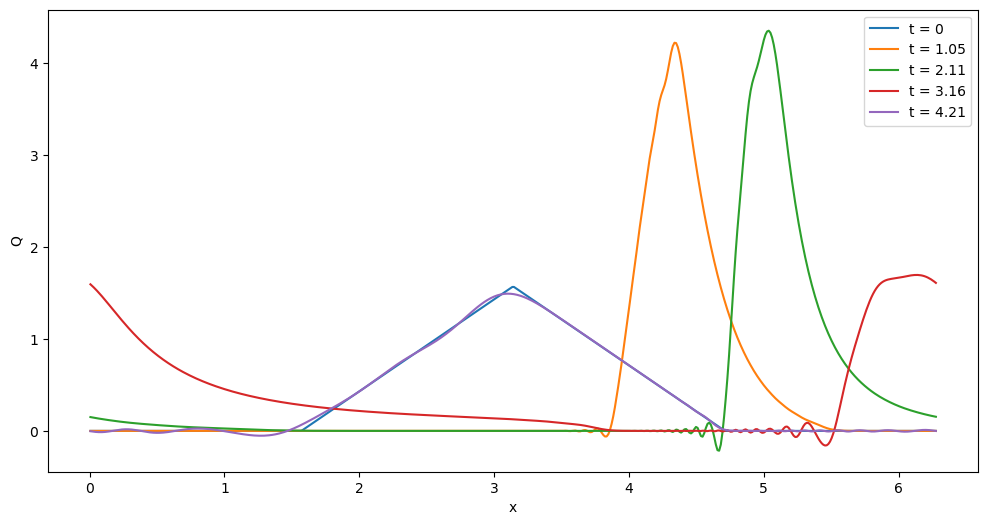

256 0.6756074200590713
512 0.442867313213663
1024 0.3031378252906123

a=16.5	 b=-0.578


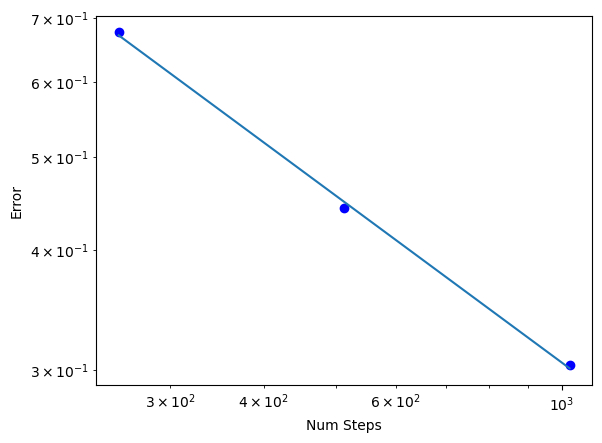

In [42]:
m=512
h = 2*np.pi/m
T = 3*np.pi/np.sqrt(5)
dt = h/(3*c)
c = 10/3

def q2(x):
    return max((np.pi/2) - np.abs(x - np.pi), 0)

dt = T/(np.ceil(T/dt/4)*4)
N = int(T/dt)
snapshots = [i * N//4 for i in range(5)]
xs = [(i+1/2)*h for i in range(m)]
Q = [q2(x) for x in xs]

plt.figure(figsize=(12,6))
plt.plot(xs, Q, label="t = 0")
for t in range(N):
    Q = step(Q, dt, h)
    if (t+1) in snapshots:
        plt.plot(xs, Q, label = f"t = {(t+1)*dt:.3}")
plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("Q")
plt.show()

errs = []
    
for m in ms:
    h = 2*np.pi/m
    T = 3*np.pi/np.sqrt(5)
    dt = h/(3*c)
    dt = T/(np.ceil(T/dt/4)*4)
    N = int(T/dt)
    
    xs = [(i+1/2)*h for i in range(m)]
    Q = np.array([q2(x) for x in xs])
    actual = np.array([q2(x) for x in xs])
    for t in range(N):
        Q = step(Q, dt, h)
    err = np.linalg.norm(Q - actual)
    print(m, err)
    errs.append(err)

C = np.asmatrix([[np.log(m), 1] for m in ms])
b, a = np.linalg.lstsq(C, np.log(errs), rcond=None)[0]

a = np.exp(a)
fit = [a*m**b for m in ms]
print(f"\na={a:.3}\t b={b:.3}")

plt.loglog(ms, errs, 'bo')
plt.loglog(ms, fit)
plt.xlabel("Num Steps")
plt.ylabel("Error")
plt.show()